<a href="https://colab.research.google.com/github/Kusuma-BM-23/Blood_Donar_Finder_App/blob/main/LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import pandas as pd

# Assuming 'df' should be a pandas DataFrame, here's an example definition:
# Replace this with your actual data loading/creation for 'df'
df = pd.DataFrame({
    'sentence': ['This is a positive sentence.', 'This is a negative sentence.', 'This is a neutral sentence.'],
    'label': [0, 1, 2] # Assuming 3 labels for a 3-class classification
})

# Prepare dataset
dataset = Dataset.from_pandas(df)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
def preprocess(examples):
    return tokenizer(examples["sentence"], truncation=True, padding=True)
dataset = dataset.map(preprocess, batched=True)

# Model setup
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)

training_args = TrainingArguments(output_dir="./results", per_device_train_batch_size=4, num_train_epochs=3, report_to="none")
trainer = Trainer(model=model, args=training_args, train_dataset=dataset)
trainer.train()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3, training_loss=1.0703639189402263, metrics={'train_runtime': 15.3719, 'train_samples_per_second': 0.585, 'train_steps_per_second': 0.195, 'total_flos': 37000324368.0, 'train_loss': 1.0703639189402263, 'epoch': 3.0})

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

num_layers = 12, chosen layer = -1, chosen head = 0


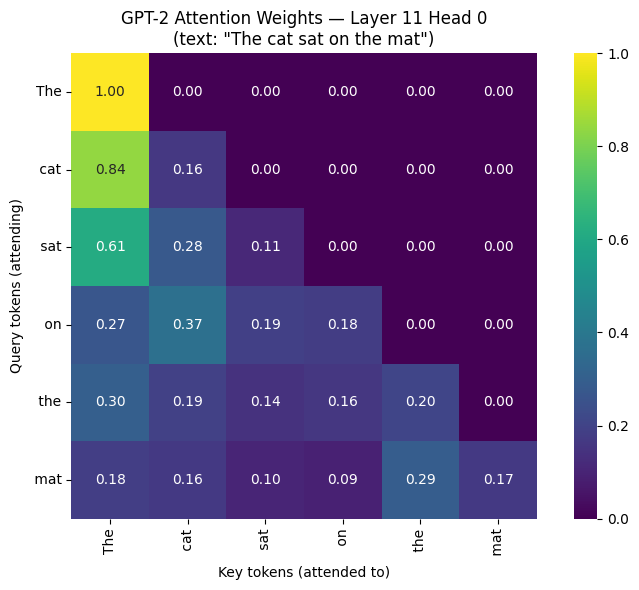


Note: GPT-2 uses causal masking. You should see near-zero attention to future tokens (upper triangle).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


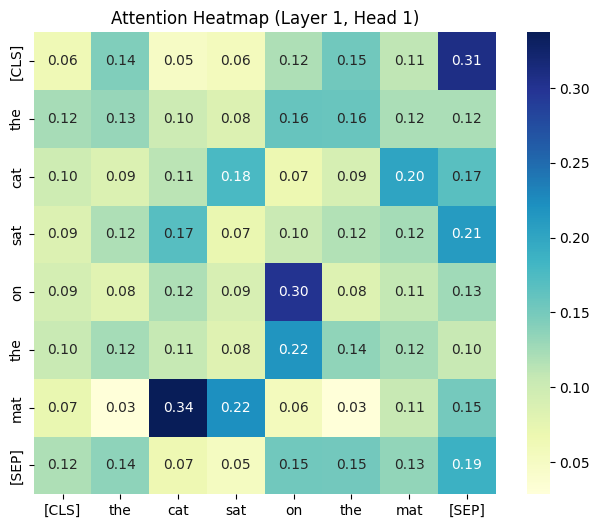

In [ ]:
  # Install dependencies (run once in Colab)
!pip install transformers torch seaborn matplotlib -q

import torch
from transformers import GPT2Tokenizer, GPT2Model
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Config ---
text = "The cat sat on the mat"
layer_idx = -1   # choose layer (use negative for counting from end)
head_idx  = 0    # choose head (0..num_heads-1)

# --- Load model & tokenizer ---
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2", output_attentions=True)
model.eval()

# --- Tokenize & forward pass ---
inputs = tokenizer(text, return_tensors="pt")    # dict with input_ids, attention_mask...
with torch.no_grad():
    outputs = model(**inputs)

# attentions: tuple(len_layers) of tensors [batch, num_heads, seq_len, seq_len]
attentions = outputs.attentions
num_layers = len(attentions)
print(f"num_layers = {num_layers}, chosen layer = {layer_idx}, chosen head = {head_idx}")
# --- Pick layer & head ---

L = num_layers

lay = (layer_idx + L) % L  # support negative index

attn_tensor = attentions[lay]          # [batch, heads, Q, K]

attn = attn_tensor[0, head_idx].cpu().numpy()  # [seq_len, seq_len]


# --- Prepare tokens for labels ---

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# Optional: make tokens more readable by replacing leading special chars

tokens_readable = [t.replace("Ġ", " ") for t in tokens]  # GPT2 shows 'Ġ' for word boundaries


# --- Plot annotated heatmap with numeric values ---

plt.figure(figsize=(max(8, len(tokens)*0.6), max(6, len(tokens)*0.45)))

sns.heatmap(attn, xticklabels=tokens_readable, yticklabels=tokens_readable,

            annot=True, fmt=".2f", cmap="viridis", cbar=True, square=True)

plt.title(f"GPT-2 Attention Weights — Layer {lay} Head {head_idx}\n(text: \"{text}\")", fontsize=12)

plt.xlabel("Key tokens (attended to)")

plt.ylabel("Query tokens (attending)")

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()


# --- Quick note printed for students ---

print("\nNote: GPT-2 uses causal masking. You should see near-zero attention to future tokens (upper triangle).")








# Install & Import dependencies

# ===============================

!pip install transformers torch matplotlib seaborn -q
import torch

import seaborn as sns

import matplotlib.pyplot as plt

from transformers import BertTokenizer, BertModel
# ===============================

# Load pre-trained BERT

# ===============================

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)
# ===============================

# Example sentence

# ===============================

sentence = "The cat sat on the mat"

inputs = tokenizer(sentence, return_tensors="pt")
# Forward pass with attentions

outputs = model(**inputs)

attentions = outputs.attentions  # List: one tensor per layer

# ===============================

# Choose one layer & one head

# ===============================

layer = 0  # First layer

head = 0   # First attention head


attention_matrix = attentions[layer][0, head].detach().numpy()


tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])


# ===============================

# Plot attention heatmap with colors

# ===============================

plt.figure(figsize=(8, 6))

sns.heatmap(

    attention_matrix,

    xticklabels=tokens,

    yticklabels=tokens,

    cmap="YlGnBu",   # yellow-green-blue color map

    cbar=True,

    square=True,

    annot=True,      # show values

    fmt=".2f"        # 2 decimal places

)

plt.title(f"Attention Heatmap (Layer {layer+1}, Head {head+1})")

plt.show()

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

prompts = [
    "What is the future of AI?",
    "Explain the importance of dialogue in AI systems."
]

for prompt in prompts:
    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    output = model.generate(input_ids, max_length=100, temperature=0.7)
    print(f"\nPrompt: {prompt}")
    print(tokenizer.decode(output[0], skip_special_tokens=True))


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Prompt: What is the future of AI?
What is the future of AI?

AI is a new field of research that is being explored by many different fields. The most important of these is the field of artificial intelligence. The field is called artificial intelligence.

The field is called artificial intelligence because it is the most advanced and most powerful form of artificial intelligence. It is the most advanced form of artificial intelligence. It is the most advanced form of artificial intelligence. It is the most advanced form of artificial intelligence. It is the most

Prompt: Explain the importance of dialogue in AI systems.
Explain the importance of dialogue in AI systems.

The AI system is a very important part of the game. It is the most important part of the game. It is the most important part of the game. It is the most important part of the game. It is the most important part of the game. It is the most important part of the game. It is the most important part of the game. It is the m

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel

class SimpleDialogueTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = AutoModel.from_pretrained("distilbert-base-uncased")
        self.fc = nn.Linear(768, 3)  # For 3 response classes

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids, attention_mask=attention_mask)
        return self.fc(outputs.last_hidden_state[:,0,:])


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
import pandas as pd

# Redefine df here to ensure it's available in this cell
df = pd.DataFrame({
    'sentence': ['This is a positive sentence.', 'This is a negative sentence.', 'This is a neutral sentence.'],
    'label': [0, 1, 2] # Assuming 3 labels for a 3-class classification
})

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["sentence"])
model = MultinomialNB()
model.fit(X, df["label"])

print(model.predict(vectorizer.transform(["This is amazing!"])))

[0]


In [ ]:

#6.	Create a program to categorize text into "Positive", "Negative", or "Neutral". Use a simple classification technique and train it on a small dataset
# !pip install sklearn

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# Small training dataset
texts = [
    "I love this product", "This is terrible", "It is okay",
    "I am very happy", "I hate this", "It’s fine",
    "This is amazing", "Not bad", "Worst experience", "Good job"
]
labels = ["Positive", "Negative", "Neutral", "Positive", "Negative",
          "Neutral", "Positive", "Neutral", "Negative", "Positive"]

# Convert text to bag-of-words vectors
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

# Train Naive Bayes classifier
model = MultinomialNB()
model.fit(X, labels)

# Test the model
test = ["I love AI", "This is bad", "It’s okay"]
for t in test:
    pred = model.predict(vectorizer.transform([t]))[0]
    print(f"Text: {t} → Sentiment: {pred}")

Text: I love AI → Sentiment: Positive
Text: This is bad → Sentiment: Negative
Text: It’s okay → Sentiment: Neutral


In [ ]:
#6
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['sentence'])

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
df['cluster'] = kmeans.labels_

print(df[['sentence', 'cluster']])


                       sentence  cluster
0  This is a positive sentence.        2
1  This is a negative sentence.        0
2   This is a neutral sentence.        1


In [ ]:
#10
import nltk, re
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Download necessary NLTK data
nltk.download('punkt_tab')      # Updated for newer NLTK versions
nltk.download('wordnet')
nltk.download('omw-1.4')        # For WordNet Lemmatizer

# Input text
text = "Cats are running faster than the dogs."

# Clean and tokenize
tokens = word_tokenize(re.sub(r'[^a-zA-Z ]', '', text.lower()))

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Output
print("Tokens:", tokens)
print("Stems:", [stemmer.stem(w) for w in tokens])
print("Lemmas:", [lemmatizer.lemmatize(w) for w in tokens])




[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Tokens: ['cats', 'are', 'running', 'faster', 'than', 'the', 'dogs']
Stems: ['cat', 'are', 'run', 'faster', 'than', 'the', 'dog']
Lemmas: ['cat', 'are', 'running', 'faster', 'than', 'the', 'dog']


In [ ]:
# Step 1: Install gensim (only needed once per runtime)
!pip install gensim

# Step 2: Import the library
from gensim.models import Word2Vec

# Step 3: Prepare your data
sentences = [
    ["good", "movie", "nice", "story"],
    ["bad", "plot", "boring", "acting"],
    ["excellent", "camera", "good", "direction"]
]

# Step 4: Train the Word2Vec model
model = Word2Vec(sentences, vector_size=50, window=3, min_count=1, sg=1)

# Step 5: View most similar words to "good"
print("Most similar words to 'good':")
print(model.wv.most_similar("good", topn=5))

# Optional: View the vector representation of any word
print("\nVector for 'good':")
print(model.wv["good"])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 12.3 MB/s eta 0:00:00
Most similar words to 'good':
[('bad', 0.13204392790794373), ('camera', 0.1267007291316986), ('nice', 0.0998455360531807), ('direction', 0.042373016476631165), ('boring', 0.012442179024219513)]

Vector for 'good':
[-1.0724545e-03  4.7286271e-04  1.0206699e-02  1.8018546e-02
 -1.8605899e-02 -1.4233618e-02  1.2917745e-02  1.7945977e-02
 -1.0030856e-02 -7.5267432e-03  1.4761009e-02 -3.0669428e-03
 -9.0732267e-03  1.3108104e-02 -9.7203208e-03 -3.6320353e-03
  5.7531595e-03  1.9837476e-03 -1.6570430e-02 -1.8897636e-02
  1.4623532e-02  1.0140524e-02  1.3515387e-02  1.5257311e-03
  1.2701781e-02 -6.8107317e-03 -1.8928028e-03  1.1537147e-02
 -1.5043275e-02 -7.8722071e-03 -1.5023164e-02 -1.8600845e-03
  1.9076237e-02 -1.4638334e-02 -4.6675373e-03 -3.8754821e-03
  1.6154874e-02 -1.1861792e-02  9.0324880e-05 -9.5074680e-03
 -1.9207101e-02  1.0014586e-02 -1.7519170e-02 -8.7836506e-03
 -7.0199967e-05 -5.9236289e-04 -1.53

In [ ]:
import numpy as np

TP, FN, FP, TN = 40, 10, 5, 45
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")



Accuracy: 0.85
Precision: 0.89
Recall: 0.80
F1 Score: 0.84


In [ ]:
#!pip install sklearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

texts = [
    ["i love ai","i hate some bad things","good teachers","not bad","that is bad but they will maintain","movie was wonderfull","that was worst concert"]
]
labels = [["positive","negative", "positive","neutral","neutral","positive","negative"]]

vectorizer = CountVectorizer()
X= vectorizer.fit_transform(texts[0]) # Pass the list directly for fit_transform

model = MultinomialNB()
model.fit(X, labels[0]) # Use .fit() method for training and pass the list directly for labels

test = ["i love this camera", "that was not bad", "it is worst "] # Renamed 'test' to 'test_sentences' to avoid conflict
for t in test:
  pred=model.predict(vectorizer.transform([t]))[0]

  print(f"Texts: {t}->Sentiment: {pred}")

Texts: i love this camera->Sentiment: positive
Texts: that was not bad->Sentiment: neutral
Texts: it is worst ->Sentiment: negative


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer


In [ ]:
df = pd.read_csv("/content/sample_data/california_housing_train.csv")
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  


In [ ]:
import pandas as pd

data = {
    "sentence":["i love this colour",
              "i hat iphone",
              "today wheather is terrible",
              "may tommarow is holiday that is good for us"],
    "sentiment":["positive","negative","negative","positive"]
}
df=pd.DataFrame(data)
print(df)

                                      sentence sentiment
0                           i love this colour  positive
1                                 i hat iphone  negative
2                   today wheather is terrible  negative
3  may tommarow is holiday that is good for us  positive


In [ ]:
!pip install transformers torch

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch

texts=["i love ai",
       "i hate this movie",
       "i want to love realy i i locve you"]

labels=[1,0,1]

tokenizer=BertTokenizer.from_pretrained("bert-base-uncased")
model=BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

tokens=tokenizer(texts,padding=True,truncation=True,return_tensors="pt")

outputs=model(**tokens,labels=torch.tensor(labels))
loss=outputs.loss
loss.backward()

print("training loss:",loss.item())

test_text="the concert was wonderfull"
inputs=tokenizer(test_text,return_tensors="pt")
pred=torch.argmax(model(**inputs).logits).item()
print("prediction sentiment:","positive" if pred == 1 else "negative")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


training loss: 0.5610679984092712
prediction sentiment: positive


In [ ]:
#7.	Cluster text documents using K-Means on TF-IDF embeddings and extract topics from the clusters.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Sample text documents
docs = [
    "AI is transforming the world",
    "Machine learning improves predictions",
    "Deep learning uses neural networks",
    "Football is a popular sport",
    "The player scored a goal",
    "Tennis is an Olympic sport"
]

# Convert to TF-IDF vectors
vec = TfidfVectorizer(stop_words='english')
X = vec.fit_transform(docs)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X)

# Show topics (top words per cluster)
terms = vec.get_feature_names_out()
for i in range(2):
    words = [terms[j] for j in kmeans.cluster_centers_[i].argsort()[-3:]]
    print(f"Cluster {i+1} top words:", words)

Cluster 1 top words: ['olympic', 'tennis', 'sport']
Cluster 2 top words: ['machine', 'predictions', 'learning']


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import pandas as pd

texts=["i love ai",
       "i hate this movie",
       "i want to love realy i i locve you"]

df = pd.DataFrame({'sentence': texts})

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['sentence'])

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X)
df['cluster'] = kmeans.labels_

print(df[['sentence', 'cluster']])

                             sentence  cluster
0                           i love ai        2
1                   i hate this movie        0
2  i want to love realy i i locve you        1


In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch


texts = [
    "I love Ai", "This movie was bad.", "Amazing experience",
    "I hate this phone.", "The food was delicious.", "Terrible weather."
]
labels = [1, 0, 1, 0, 1, 0]

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)

tokens = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")


outputs = model(**tokens, labels=torch.tensor(labels))
loss = outputs.loss
loss.backward()
print("Training loss:", loss.item())


test_text = "The concert was wonderful!"
inputs = tokenizer(test_text, return_tensors="pt")
pred = torch.argmax(model(**inputs).logits).item()
print("Predicted Sentiment:", "Positive" if pred == 1 else "Negative")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training loss: 1.1008092164993286
Predicted Sentiment: Negative


In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

texts = ["i love this product","this one is not good","not bad","it will cause not thatmuch","bad plot boring action"]

labels=["positive","negative","neutral","neutral","negative"]

vectorizer = CountVectorizer()
X=vectorizer.fit_transform(texts)

model = MultinomialNB()
model.fit(X,labels)

test = ["i love AI!","this one is bad","not bad"]
for t in test:
  pred = model.predict(vectorizer.transform([t]))[0]
  print(f"\nText: {t}->sentence: {pred}")


Text: i love AI!->sentence: positive

Text: this one is bad->sentence: negative

Text: not bad->sentence: neutral


In [12]:
!git clone https://github.com/Kusuma-BM-23/LLM.git

Cloning into 'LLM'...


In [14]:
!ls

LLM  sample_data


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
!find /content/drive -name "*.ipynb"

/content/drive/MyDrive/Colab Notebooks/LLM.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled6.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled7.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled8.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled9.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled10.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled11.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled13.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled14.ipynb
/content/drive/MyDrive/Colab Notebooks/KUSUMA_1nt23is108_secB.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled16.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled18.ipynb
/content/drive/MyDrive/Colab Notebooks/Kusuma.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled19.ipynb

In [18]:
import shutil

shutil.copy(
    "/content/drive/MyDrive/Colab Notebooks/LLM.ipynb",
    "/content/LLM/"
)

'/content/LLM/LLM.ipynb'

In [19]:
%cd /content/LLM

/content/LLM


In [20]:
!ls

LLM.ipynb


In [22]:
!git config --global user.name "Kusuma-BM-23"
!git config --global user.email "kusumabm63@gmail.com"

In [23]:
!git add .
!git commit -m "Added LLM notebook"

[main (root-commit) 5ee44e4] Added LLM notebook
 1 file changed, 1 insertion(+)
 create mode 100644 LLM.ipynb


In [24]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address
